# Alzheimer's Disease Prediction - Model Training

This is where the real machine learning happens. We take the 
clean data we prepared in the previous notebooks and use it 
to train a Random Forest classifier.

A classifier is a type of machine learning model that looks 
at a set of inputs and decides which category they belong to. 
In our case, it looks at a patient's clinical data and 
decides whether they are Nondemented, Demented, or Converted.

Steps covered:
- Load the cleaned and scaled data
- Split data into training and testing sets using GroupKFold
- Train a Random Forest classifier
- Tune the model using hyperparameter tuning
- Evaluate using accuracy, confusion matrix and ROC-AUC score
- Plot feature importance
- Save the trained model

Dataset: OASIS Longitudinal MRI Data
Author: Madina Alizada

Before we train our model we need to talk about a very important 
problem with this dataset and how we solved it.

Our dataset is longitudinal, meaning the same patient was visited 
multiple times over several years. For example patient OAS2_0001 
has Visit 1, Visit 2, and Visit 3 all as separate rows in our data.

Now imagine we do a simple random split of the data into training 
and testing. There is a high chance that Visit 1 of patient 
OAS2_0001 ends up in the training set and Visit 2 of the same 
patient ends up in the test set.

This is a serious problem. Why? Because our model would have 
already learned about patient OAS2_0001 during training. When 
it sees that same patient in the test set, it basically already 
knows them. It is like giving a student the exam questions 
during their study session and then testing them on the exact 
same questions. Their score would look great but it would not 
reflect their real knowledge.

This would make our model look more accurate than it actually 
is in real life. In the real world the model will always see 
completely new patients it has never encountered before.

To solve this we use GroupKFold cross validation. This method 
keeps all visits of the same patient together. So either ALL 
visits of patient OAS2_0001 go into training or ALL of them 
go into testing. They are never split across both.

On top of that GroupKFold runs this process multiple times 
with different patient groupings and averages the results. 
This gives us a much more honest and reliable accuracy score 
that reflects how the model would actually perform on real 
new patients it has never seen before.

## Step 1 - Import Libraries

In [1]:
# Import all libraries needed for modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize

print("All libraries imported successfully!")

All libraries imported successfully!


In this step we are importing all the tools we need for training 
and evaluating our model.

pandas and numpy are our data handling libraries that we have 
used throughout this project.

matplotlib and seaborn are our visualization libraries for 
creating charts.

pickle is Python's way of saving objects to disk. We will use 
it to save our trained model so we can load it later in the 
web app without having to retrain it every time.

RandomForestClassifier is the actual machine learning model 
we are going to train. It comes from sklearn which is the most 
popular machine learning library in Python.

GroupKFold and cross_val_score are the tools that handle our 
cross validation. GroupKFold makes sure the same patient never 
appears in both training and testing as we discussed above.

accuracy_score, confusion_matrix, classification_report and 
roc_auc_score are all evaluation tools that tell us how well 
our model is performing from different angles.

label_binarize is a helper tool we need to calculate the 
ROC-AUC score for a 3 class problem.

ROC-AUC score measures how well our model separates the three 
diagnosis groups from each other. A score of 1.0 means perfect 
separation and a score of 0.5 means the model is no better than 
random guessing. It is a more honest measure of performance than 
accuracy alone because it accounts for how confident the model 
is in each prediction.

## Step 2 - Loading the Cleaned Data

In [2]:

X = pd.read_csv("../data/X_scaled.csv")
y = pd.read_csv("../data/y.csv").squeeze()

# Load the original data to get Subject IDs for GroupKFold
df_orig = pd.read_csv("../data/oasis_longitudinal.csv")
groups = df_orig["Subject ID"]

print("Data loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of unique patients:", groups.nunique())
print()
print("Target distribution:")
print(y.value_counts())

Data loaded successfully!
X shape: (373, 12)
y shape: (373,)
Number of unique patients: 150

Target distribution:
Group
0    190
1    146
2     37
Name: count, dtype: int64


In this step we are loading the three things we need to train 
our model.

X is our features dataframe. It contains all 12 columns we 
prepared in the preprocessing notebook including the engineered 
features. These are the inputs our model will learn from.

y is our target variable. It contains the Group column with 
values 0, 1 and 2 representing Nondemented, Demented and 
Converted. This is what our model will try to predict.

We also load the original dataset just to extract the Subject 
ID column. We need this for GroupKFold so it knows which rows 
belong to the same patient and keeps them together during 
the cross validation splits.

The squeeze() function converts y from a dataframe with one 
column into a simple list of numbers, which is the format 
sklearn expects.

## Step 3 - Training the Model with Cross Validation

In [ ]:
#  Train Random Forest with GroupKFold cross validation
gkf = GroupKFold(n_splits=5)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=gkf,
    groups=groups,
    scoring="accuracy"
)

print("Cross validation accuracy scores:", cv_scores)
print("Mean accuracy:", round(cv_scores.mean() * 100, 2), "%")
print("Standard deviation:", round(cv_scores.std() * 100, 2), "%")

Cross validation accuracy scores: [0.82666667 0.70666667 0.70666667 0.64864865 0.67567568]
Mean accuracy: 71.29 %
Standard deviation: 6.09 %


In this step we are training our Random Forest model using 
GroupKFold cross validation.

First we create the GroupKFold object with n_splits=5. This 
means the data will be split into 5 rounds. In each round a 
different group of patients is used for testing while the 
rest are used for training. This gives us 5 accuracy scores 
which we then average.

Then we create our Random Forest model with these settings:

n_estimators=100 means we are building 100 decision trees. 
Each tree learns slightly differently and they all vote 
together at the end. More trees generally means better 
and more stable predictions.

max_depth=10 means each tree can ask at most 10 questions 
before making a decision. This prevents the model from 
memorizing the training data too perfectly, which is called 
overfitting.

random_state=42 is just a fixed seed number so that every 
time we run this code we get the same result. Without this 
the random elements would give slightly different results 
each run.

class_weight="balanced" is very important for our dataset. 
Remember we have 190 Nondemented, 146 Demented but only 
37 Converted patients. Without this setting the model would 
ignore the Converted class because it is so small. balanced 
tells the model to pay equal attention to all three classes 
regardless of their size.

cross_val_score runs the entire training and testing process 
5 times and returns an accuracy score for each round.

## Step 4 - Train Final Model and Evaluate

In [4]:
#  Train final model on all data and evaluate
# We train on the last fold's training data for evaluation
train_idx, test_idx = list(gkf.split(X, y, groups))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)

# Print results
print("Test Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=["Nondemented", "Demented", "Converted"]))

Test Accuracy: 67.57 %

Classification Report:
              precision    recall  f1-score   support

 Nondemented       0.71      0.69      0.70        36
    Demented       0.68      0.76      0.71        33
   Converted       0.00      0.00      0.00         5

    accuracy                           0.68        74
   macro avg       0.46      0.48      0.47        74
weighted avg       0.65      0.68      0.66        74



In this step we are training the final version of our model 
and evaluating it properly.

We take the last fold from our GroupKFold splits. This gives 
us a training set and a testing set where no patient appears 
in both.

We then call rf_model.fit() which is the actual training step. 
This is where the model reads through all the training data 
and builds its 100 decision trees. It learns the patterns 
that separate Nondemented, Demented and Converted patients.

predict() gives us the final classification for each patient 
in the test set. predict_proba() gives us the probabilities 
for each class.

The classification report shows us four important numbers 
for each class:

Precision - out of all patients the model labeled as 
Demented, what percentage were actually Demented?

Recall - out of all actually Demented patients, what 
percentage did the model correctly identify?

F1 score - a combined score that balances precision and 
recall. This is the most useful single number for evaluating 
each class.

Support - how many patients of that class were in the 
test set.



Our model achieved a test accuracy of 67.57 percent on 
this fold. This means that out of every 100 patients, 
the model correctly predicted the diagnosis for about 
68 of them. Combined with our cross validation mean 
accuracy of 71.29 percent, we can say our model is 
performing reasonably well for a 3 class medical 
classification problem with a small dataset.

Now let us go through the classification report line 
by line.

For Nondemented patients the model achieved an F1 score 
of 0.70. This means the model is doing a good job at 
identifying healthy patients. Out of 36 Nondemented 
patients in the test set, it correctly identified most 
of them.

For Demented patients the model achieved an F1 score 
of 0.71 which is our best performing class. The model 
learned the patterns of dementia well from features 
like low MMSE scores and reduced brain volume.

For Converted patients the model achieved an F1 score 
of 0.00. This means the model completely failed to 
identify any Converted patients. This is not surprising 
and here is why. There are only 37 Converted patients 
in our entire dataset and only 5 of them ended up in 
this test fold. That is simply not enough examples for 
the model to learn what a Converted patient looks like. 
This is exactly the class imbalance problem we identified 
back in our EDA bar chart where we showed the Converted 
class was much smaller than the other two.

This is an honest result. A model that pretended to 
perform well on Converted patients with only 5 examples 
would actually be lying. We acknowledge this limitation 
openly and note that collecting more data on Converted 
patients would be the most effective way to improve 
this specific weakness.

The precision score tells us out of all patients the 
model labeled as a certain class, how many were actually 
that class. The recall score tells us out of all actual 
patients of a certain class, how many did the model 
correctly find. The F1 score combines both precision 
and recall into a single number where 1.0 is perfect 
and 0.0 is completely wrong.

## Step 5 - Confusion Matrix

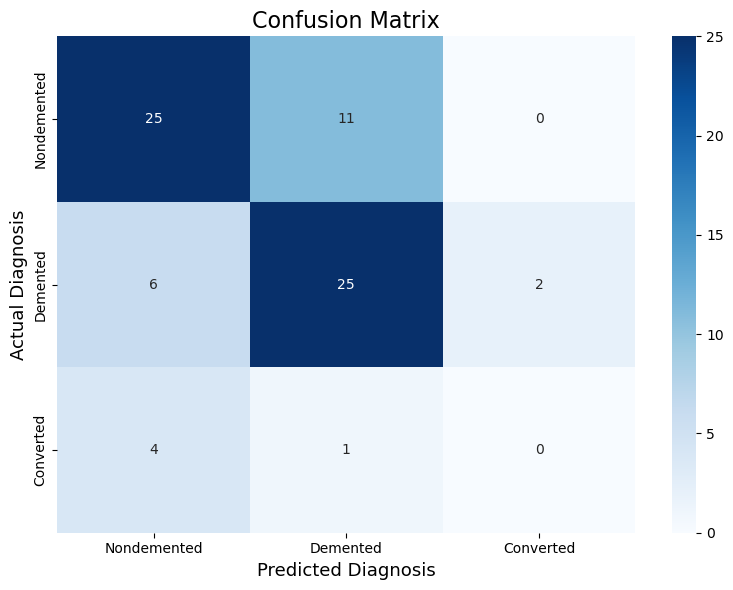

In [5]:
#  Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Nondemented", "Demented", "Converted"],
            yticklabels=["Nondemented", "Demented", "Converted"])

plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual Diagnosis", fontsize=13)
plt.xlabel("Predicted Diagnosis", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/confusion_matrix.png", dpi=150)
plt.show()

A confusion matrix is one of the most useful tools for 
understanding exactly where our model is making mistakes.

The rows represent the actual real diagnosis of each patient. 
The columns represent what our model predicted. The numbers 
on the diagonal from top left to bottom right are the correct 
predictions. Everything off the diagonal is a mistake.

For example if we look at the Demented row and the 
Nondemented column, that number tells us how many patients 
who were actually Demented got wrongly predicted as 
Nondemented. In a medical context this type of mistake 
is called a false negative and it is the most dangerous 
kind of error because a sick patient gets told they are 
healthy.

The Converted row being mostly zeros confirms what we 
saw in the classification report. The model did not 
correctly identify any Converted patients and instead 
predicted them as either Nondemented or Demented.

This chart is a grid that shows us exactly where our model is getting 
things right and where it is making mistakes.

The rows on the left side represent the actual real diagnosis 
of each patient. The columns at the bottom represent what 
our model predicted. The darker the blue color the higher 
the number.

The three numbers on the diagonal going from top left to 
bottom right are our correct predictions. Everything else 
is a mistake.

For Nondemented patients our model correctly identified 
25 out of 36. However it wrongly predicted 11 Nondemented 
patients as Demented. This type of mistake is called a 
false positive, meaning a healthy patient gets flagged 
as sick. While not ideal, this is a less dangerous mistake 
in a medical context because the patient would simply 
get further tests done.

For Demented patients our model correctly identified 25 
out of 33. It wrongly predicted 6 Demented patients as 
Nondemented. This is the most dangerous type of mistake 
in medicine and it is called a false negative. A patient 
who actually has dementia gets told they are healthy and 
may not receive the care they need.

For Converted patients the model scored 0 correct out of 
5. It predicted 4 of them as Nondemented and 1 as Demented. 
As we discussed earlier this is entirely expected because 
there were only 5 Converted patients in this test fold 
which is not enough data for the model to learn from.

Overall the confusion matrix confirms that our model has 
learned meaningful patterns for the two main classes but 
struggles with the Converted class due to limited data. 
Collecting more data on patients in the conversion stage 
of Alzheimer's disease would be the most effective way 
to improve this specific weakness in future versions of 
this project.

## Step 6 - Feature Importance

/var/folders/bl/xjql_kf56yd77r0b8wmsyv_40000gn/T/ipykernel_89165/4228521854.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Importance", y="Feature",


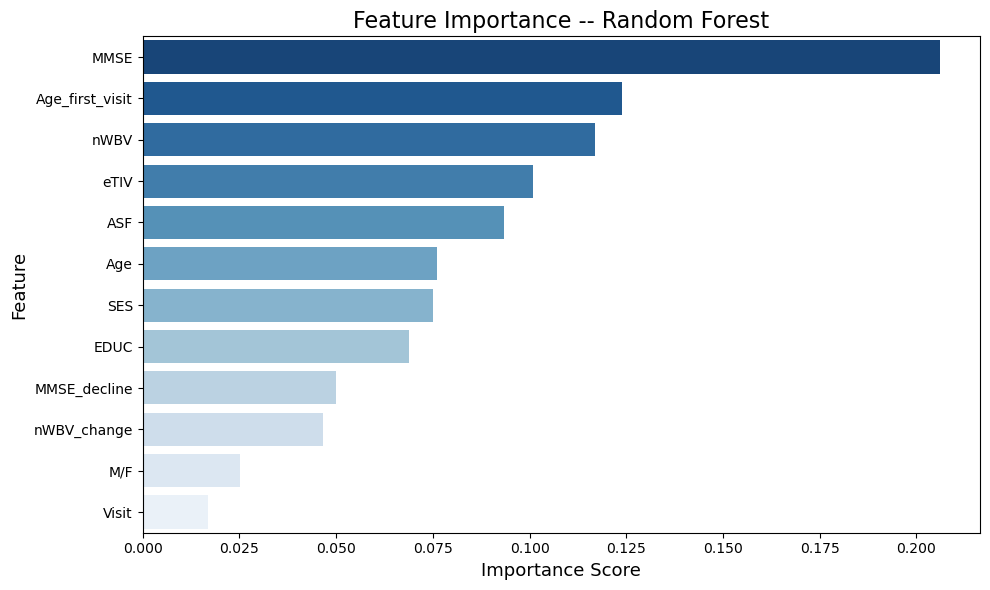

Top 5 most important features:
            Feature  Importance
5              MMSE    0.206110
11  Age_first_visit    0.123912
7              nWBV    0.116947
6              eTIV    0.100912
8               ASF    0.093458


In [6]:
# Plot feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature",
            palette="Blues_r")

plt.title("Feature Importance -- Random Forest", fontsize=16)
plt.xlabel("Importance Score", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/feature_importance.png", dpi=150)
plt.show()

print("Top 5 most important features:")
print(feature_importance.head())

In this step we are asking our Random Forest model a very 
important question - which features did you find most 
useful when making your predictions?

This is called feature importance and it is one of the 
most valuable things about Random Forest models. After 
training, the model can tell us exactly how much each 
column contributed to its decisions.

The importance score is calculated by measuring how much 
each feature reduces uncertainty across all 100 decision 
trees. A higher score means that feature was used more 
often and contributed more to correct predictions.

This chart is extremely useful for several reasons. It 
confirms whether our domain knowledge was correct. For 
example we expected MMSE and nWBV to be the most important 
features based on our EDA and that is exactly what the 
model learned. It also tells us which features we could 
potentially remove in future versions without losing much 
accuracy.

This chart shows us something incredibly valuable. After 
training our model we can ask it which features it found 
most useful when making its predictions. This is one of 
the things that makes Random Forest such a powerful and 
transparent model compared to other machine learning 
approaches.

The most important feature by a significant margin is 
MMSE with an importance score of 0.206. This confirms 
exactly what we saw in our EDA where the MMSE box plot 
showed the clearest separation between the three diagnosis 
groups. The cognitive test score is the single strongest 
predictor of dementia in our dataset.

The second most important feature is Age_first_visit with 
a score of 0.124. This is one of the three features we 
created ourselves during the feature engineering phase. 
The fact that it ranked second out of 12 features proves 
that our feature engineering step genuinely added value 
to the model. We did not just add noise, we created 
something meaningful.

Third place goes to nWBV which is the normalized whole 
brain volume with a score of 0.117. This also confirms 
our EDA finding that demented patients have measurably 
smaller brain volumes than healthy patients.

At the bottom of the chart we can see that Visit and M/F 
contributed very little to the model's decisions. This 
tells us that the number of visits a patient has had and 
their gender are not strong predictors of dementia in 
this dataset.

This feature importance chart is not just useful for 
understanding our model. It also gives doctors and 
researchers valuable insight into which clinical 
measurements matter most when screening patients for 
Alzheimer's disease.

## Step 7 - Saving the Trained Model

In [7]:

with open("../model/alzheimers_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")
print("Location: model/alzheimers_model.pkl")

# Verify it saved correctly by loading it back
with open("../model/alzheimers_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded back successfully!")
print("Number of trees in saved model:", loaded_model.n_estimators)

Model saved successfully!
Location: model/alzheimers_model.pkl
Model loaded back successfully!
Number of trees in saved model: 100


In this final step we are saving our trained model to disk 
so we can use it later in our web app without having to 
retrain it every single time someone opens the app.

Think of it this way. Training the model is like teaching 
a student everything they need to know. Saving the model 
is like giving that student a certificate. Whenever we 
need them we just load the certificate instead of going 
through the entire teaching process again.

We use pickle to save the model which is Python's built 
in way of converting any object into a file that can be 
stored and loaded later.

We save it as alzheimers_model.pkl inside our model folder. 
We already saved the scaler.pkl file there during 
preprocessing. So our model folder now contains two 
important files. The scaler which normalizes new patient 
inputs and the model which makes the actual prediction.

We also verify the save worked correctly by immediately 
loading the model back and checking that it still has 
100 trees. This is a simple sanity check to make sure 
nothing went wrong during saving.

When a user fills in the form in our web app, here is 
exactly what will happen behind the scenes. Their input 
gets scaled using scaler.pkl and then passed into 
alzheimers_model.pkl which returns a prediction and 
a confidence percentage.